# Coding Assignment 3

In [1]:
# Imports
import pandas as pd
from ISLP import load_data
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


## Load `Wage` data

In [2]:
wage_df = load_data("Wage")

In [3]:
# quick preview of the data
wage_df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


## a) Split the data: 70% training, 30% testing
Some of the variables are categorical, so I'll need to create dummy variables for them in order to use them in my regression. Also, the dataset contains `logwage`, which is the log of the `wage` variable. We need to remove this if we plan to use `wage` as our target variable.

In [4]:
X = wage_df.drop(columns=['wage', 'logwage'])
y = wage_df["wage"]

# Convert the categorical variables into dummy variables 
X_dummies = pd.get_dummies(X, drop_first=True)

In [5]:
X_dummies.head()

,year,age,maritl_2. Married,maritl_3. Widowed,maritl_4. Divorced,maritl_5. Separated,race_2. Black,race_3. Asian,race_4. Other,education_2. HS Grad,education_3. Some College,education_4. College Grad,education_5. Advanced Degree,jobclass_2. Information,health_2. >=Very Good,health_ins_2. No
0,2006,18,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,2004,24,False,False,False,False,False,False,False,False,False,True,False,True,True,True
2,2003,45,True,False,False,False,False,False,False,False,True,False,False,False,False,False
3,2003,43,True,False,False,False,False,True,False,False,False,True,False,True,True,False
4,2005,50,False,False,True,False,False,False,False,True,False,False,False,True,False,False


In [6]:
y.head()

0     75.043154
1     70.476020
2    130.982177
3    154.685293
4     75.043154
Name: wage, dtype: float64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.3, random_state=598)

## b) Fit a decision tree and visualize it

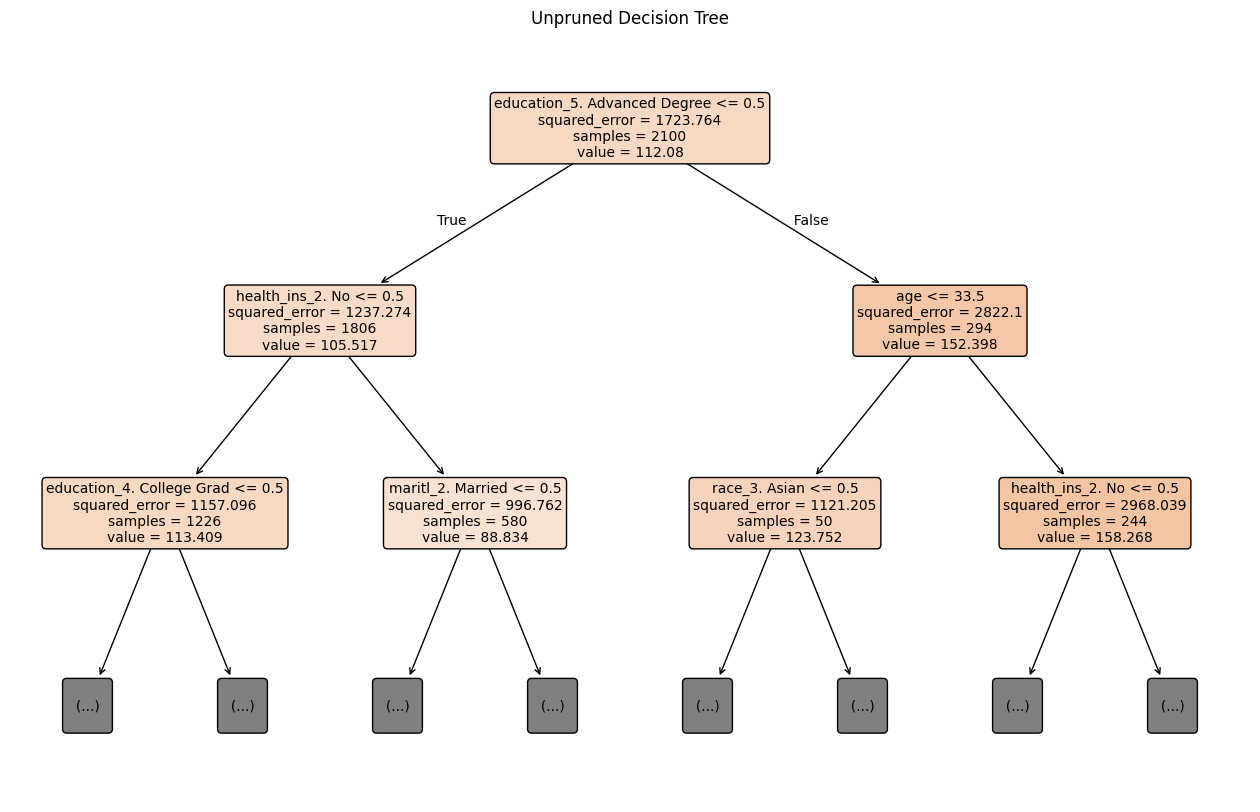

In [8]:
# Fit an unpruned decision tree 
tree_unpruned = DecisionTreeRegressor(random_state=598)
tree_unpruned.fit(X_train, y_train)

# Visualize the unpruned tree
plt.figure(figsize=(16,10))
plot_tree(
    tree_unpruned,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=2,  
    fontsize=10
)
plt.title("Unpruned Decision Tree")
plt.show()

### Interpretation of the unpruned tree

The `value` field within each split represents the average `wage` of that split's sample. For this interpretation, I'm assuming that any data point that falls within that split, their predicted `wage` will be around `value`. 

1. Root split: `education_5. Advanced Degree <= 0.5`
    - The syntax of this is a bit strange but essentially, since this is a binary variable, `education_5. Advanced Degree = 0` means that the person does not have an advanced degree, and `education_5. Advanced Degree = 1` means the person does have an advanced degree. 
    - So, if a person does not have an advanced degree, we'd follow the "True" path (left). Those without an advanced degree would have an estimated wage of 105.52. 
    - Those with an advanced degree would have an estimated wage of 152.40.
    - In conclusion, on average, those with an advanced degree earn significantly more than those without one. 

2. Second split (left branch): `health_ins_2. No <= 0.5`
    - For those without an advanced degree, the next most predictive predictor is whether or not they have health insurance. 
    - If they have health insurance, their estimated wage is 113.41. 
    - If they do not have health insurance, their estimated wage is 88.84.
    - In conclusion, out of the people without an advanced degree, those who have health insurance make more compared to those who do not have health insurance.

3. Second split (right branch): `age <= 33.5`
    - For those with an advanced degree, the next most predictive split is ages <= 33.5 and > 33.5. 
    - If a person holds an advanced degree and is below or is the age of 33.5, their estimated wage is 123.75. 
    - If a person holds an advanced degree and is above 33.5, their estimated wage is 158.27. 
    - In conclusion, out of those with an advanced degree, those older than 33.5 make more compared to those younger than and who are 33.5. 


## c) Prune the tree using cross-validation

In [9]:
# Prune using the cost-complexity pruning path 
path = tree_unpruned.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
param_grid = {'ccp_alpha': ccp_alphas}
base_tree = DecisionTreeRegressor(random_state=42)
grid = GridSearchCV(base_tree, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)
best_alpha = grid.best_params_['ccp_alpha']

In [10]:
# Fit pruned tree
tree_pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
tree_pruned.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,np.float64(14.126642798790954)


### Evaluate prune vs. unpruned trees using mean squared error

In [17]:
y_pred_pruned = tree_pruned.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)

y_pred_unpruned = tree_unpruned.predict(X_test)
mse_unpruned = mean_squared_error(y_test, y_pred_unpruned)

print(f"Unpruned tree test MSE: {mse_unpruned:.4f}")
print(f"Pruned tree test MSE: {mse_pruned:.4f}")


Unpruned tree test MSE: 2592.9753
Pruned tree test MSE: 1337.6345


Interpretation: The pruned test MSE less than the unpruned test MSe by about 1200. This means that pruning the decision tree did help with its predictability. 

## d) Fit a random forest 

In [12]:
# Random forest with smaller max_features
rf_small = RandomForestRegressor(
    n_estimators=500,     
    max_features=3,         
    random_state=42
)
rf_small.fit(X_train, y_train)
y_pred_small = rf_small.predict(X_test)
mse_small = mean_squared_error(y_test, y_pred_small)
print(f"Random Forest (max_features=3) Test MSE: {mse_small:.4f}")

Random Forest (max_features=3) Test MSE: 1356.9178


In [13]:
# Random forest with larger max_features
rf_large = RandomForestRegressor(
    n_estimators=500,
    max_features=10,      
    random_state=42
)
rf_large.fit(X_train, y_train)
y_pred_large = rf_large.predict(X_test)
mse_large = mean_squared_error(y_test, y_pred_large)
print(f"Random Forest (max_features=10) Test MSE: {mse_large:.4f}")

Random Forest (max_features=10) Test MSE: 1433.6720


Interpretation: Increasing the number of `max_features` does not improve the model's performance. This suggests that having more randomness helped the model generalize better. Also using too many features per split (like 10) might have caused overfitting.

## e) Most important predictors in the random forest model with `max_features = 3`

In [18]:
importances = rf_small.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10))


Top 10 most important features:
                         Feature  Importance
1                            age    0.406950
0                           year    0.143265
12  education_5. Advanced Degree    0.114599
15              health_ins_2. No    0.077237
2              maritl_2. Married    0.051601
13       jobclass_2. Information    0.035511
11     education_4. College Grad    0.034478
9           education_2. HS Grad    0.034364
14         health_2. >=Very Good    0.028513
10     education_3. Some College    0.021158


Interpretation: 
- `age` is the most important variable. This logistically makes sense because `wage` usually is tied to a person's experience. If you are older, you tend to have more experience, and thus make more money. 
- `year` is the second most important variable. This means that the year the survey was conducted is influential in predicting wages. This makes sense because every year there can be many different external factors (i.e. inflation, economic growth, or policy changes) that can affect wage. 
- The remaining important features are related to education level, marital status, job class and health insurance. It makes sense that these would characteristics of a person would greatly influence a person's wage. Those with higher education, tend to have higher paying jobs that would provide them health insurance. Also, those who are married are in more stable positions in life and thus have higher paying/stable jobs. 

## f) Random Forest test MSE vs. Pruned regression tree test MSE

| Model                             | Test MSE |
| --------------------------------- | -------- |
| Pruned Regression Tree            | 1337.6345 |
| Random Forest (max_features = 3)  | 1356.9178  |

On this test set, the pruned regression tree slightly outperforms the random forest in terms of MSE. However, the difference is very small. Random forests are generally more robust and less sensitive to data noise, so they may still perform better on other samples or in practice.

## g) Fit a GBM

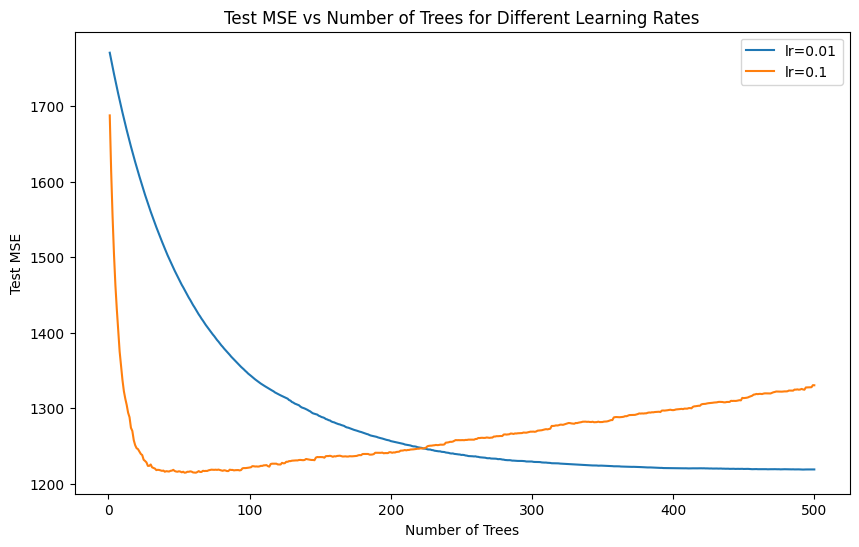

In [15]:
learning_rates = [0.01, 0.1]

# Store test MSE for plotting
mse_dict = {}

for lr in learning_rates:
    gbm = GradientBoostingRegressor(
        n_estimators=500,   # max number of trees
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    gbm.fit(X_train, y_train)
    
    # Predict on test set for each stage 
    test_mse = []
    for y_pred_stage in gbm.staged_predict(X_test):
        test_mse.append(mean_squared_error(y_test, y_pred_stage))
    
    mse_dict[lr] = test_mse

# Plot test MSE vs number of trees
plt.figure(figsize=(10,6))
for lr in learning_rates:
    plt.plot(range(1, len(mse_dict[lr])+1), mse_dict[lr], label=f'lr={lr}')
plt.xlabel('Number of Trees')
plt.ylabel('Test MSE')
plt.title('Test MSE vs Number of Trees for Different Learning Rates')
plt.legend()
plt.show()

In [19]:
# Fit GBM with one of the learning rates (e.g., 0.1) for variable importance
gbm = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)
gbm.fit(X_train, y_train)

# Feature importances
importances = gbm.feature_importances_
features = X_train.columns
importance_df = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)

print("Top 2 influential variables:")
print(importance_df[:2])

Top 2 influential variables:
[('education_5. Advanced Degree', np.float64(0.29082325480594945)), ('age', np.float64(0.2137580221631327))]


Interpretation: 
- The two most influential factors for wage are whether a person holds an advanced degree and age. This makes perfect sense because those with advanced degrees have higher paying jobs. As for age, jobs tend to pay based off of experience. So if you have more experience, you get paid higher, and usually someone who is older has more experience.

## h) GBM vs. Random Forest vs. Pruned Decision Tree Test MSE

In [20]:
# calculate GBM test MSE
y_pred_gbm = gbm.predict(X_test)
mse_gbm = mean_squared_error(y_test, y_pred_gbm)
print(f"GBM Test MSE: {mse_gbm:.4f}")

GBM Test MSE: 1330.2206


### Comparison

| Model                            | Test MSE |
| -------------------------------- | -------- |
| Pruned Regression Tree           | 1337.63  |
| Random Forest (max_features = 3) | 1356.92  |
| GBM (example)                    | 1330.22 |

- GBM has the lowest test MSE (1330.22) → best predictive performance on the test set.
- Pruned regression tree is next (1337.63) → slightly worse than GBM, still performs reasonably well.
- Random forest (1356.92) → slightly worse compared to other two, but again still performs reasonably well.
- The differences are small (~7 points between GBM and pruned tree, ~26 points between GBM and RF), so all models are performing similarly in magnitude, but GBM is slightly more accurate.
